# IPR Market-Making Grid Search

Two strategies for INTARIAN_PEPPER_ROOT (L=80):
- **k=0**: fill entire L via taker orders (current template)
- **k>0**: take L-k aggressively, quote a maker bid at bid_wall+1 for remaining k shares

Grid search k in [0..20]; for each k run the full backtester across all 3 days.

In [1]:
import csv
import json
import io
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import List, Dict, Any, Optional
import sys
sys.path.insert(0, '..')
from datamodel import TradingState, Listing, OrderDepth, Trade, Order, Observation

In [2]:
BASE  = '../imc-prosperity-4-backtester/prosperity4bt/resources/round1'
DAYS  = ['-2', '-1', '0']
POS_LIMIT = 80
IPR = 'INTARIAN_PEPPER_ROOT'
ACO = 'ASH_COATED_OSMIUM'

# --- load prices and trades for all days ---
price_frames = []
trade_frames = []
offset = 0

ipr_ia_all = []

for day in DAYS:
    pdf = pd.read_csv(f'{BASE}/prices_round_1_day_{day}.csv', sep=';'  )
    pdf['timestamp'] += offset
    price_frames.append(pdf)

    tdf = pd.read_csv(f'{BASE}/trades_round_1_day_{day}.csv', sep=';'  )
    tdf['timestamp'] += offset
    trade_frames.append(tdf)

    ipr_ts = tdf[tdf['symbol'] == IPR]['timestamp'].sort_values().values
    ia = np.diff(ipr_ts).astype(float)
    ipr_ia_all.extend(ia[ia > 0].tolist())

    offset += 1_000_000

all_prices = pd.concat(price_frames, ignore_index=True)
all_trades = pd.concat(trade_frames, ignore_index=True)
ipr_trades_all = all_trades[all_trades['symbol'] == IPR]

ipr_ia = np.array(ipr_ia_all)
lam     = 1.0 / ipr_ia.mean()

# slope from first/last mid of IPR
ipr_prices = all_prices[all_prices['product'] == IPR].sort_values('timestamp')
slope = (ipr_prices['mid_price'].iloc[-1] - ipr_prices['mid_price'].iloc[0]) /         (ipr_prices['timestamp'].iloc[-1] - ipr_prices['timestamp'].iloc[0])

# order size distribution
qtys  = ipr_trades_all['quantity'].values
sizes, counts = np.unique(qtys, return_counts=True)
size_pmf = dict(zip(sizes.tolist(), (counts / counts.sum()).tolist()))

print(f'slope        : {slope:.6f}  price/tick')
print(f'lambda (IPR) : {lam:.6f}  trades/tick')
print(f'E[wait]      : {1/lam:.1f}  ticks')
print(f'min spread   : {slope/lam:.4f}  (slope/lambda)')
print()
print('Order size PMF:')
for s, p in size_pmf.items():
    print(f'  size={s}  prob={p:.4f}')
print(f'E[size]      : {sum(s*p for s,p in size_pmf.items()):.3f}')

slope        : 0.001001  price/tick
lambda (IPR) : 0.000336  trades/tick
E[wait]      : 2978.1  ticks
min spread   : 2.9797  (slope/lambda)

Order size PMF:
  size=2  prob=0.0010
  size=3  prob=0.1958
  size=4  prob=0.1592
  size=5  prob=0.1929
  size=6  prob=0.2166
  size=7  prob=0.1929
  size=8  prob=0.0415
E[size]      : 5.173


In [3]:
# Optimal bid price analysis
# For a maker bid at bid_wall+1 (inside spread = best bid), we capture any bot sell.
# E[profit per bot sell] = sum_i P(bot_sells_i) * min(i, k) * (mid - bid)
# mid - bid  ~  half_spread - 1  ~  5.5 on average (spread mean 13)

half_spread = 13.05 / 2  # mean half-spread
bid_edge    = half_spread - 1   # quoting at bid_wall+1

# Expected fill shares as a function of k (remaining capacity)
def expected_fill(k):
    total = 0.0
    for s, p in size_pmf.items():
        total += p * min(s, k)
    return total

print('k    E[fill]  E[profit per bot trade]')
for k in range(0, 21):
    ef = expected_fill(k)
    ep = ef * bid_edge
    print(f'{k:<4} {ef:.3f}    {ep:.3f}')

k    E[fill]  E[profit per bot trade]
0    0.000    0.000
1    1.000    5.525
2    2.000    11.050
3    2.999    16.570
4    3.802    21.007
5    4.446    24.565
6    4.897    27.057
7    5.132    28.352
8    5.173    28.581
9    5.173    28.581
10   5.173    28.581
11   5.173    28.581
12   5.173    28.581
13   5.173    28.581
14   5.173    28.581
15   5.173    28.581
16   5.173    28.581
17   5.173    28.581
18   5.173    28.581
19   5.173    28.581
20   5.173    28.581


In [4]:
# Backtester (adapted from example — IPR-only, marks at mid price)
class Backtester:
    def __init__(self, trader, listings, position_limit, fair_marks, market_data, trade_history):
        self.trader         = trader
        self.listings       = listings
        self.market_data    = market_data.copy()
        self.position_limit = position_limit
        self.fair_marks     = fair_marks
        self.trade_history  = trade_history.sort_values(by=['timestamp', 'symbol'])

        self.observations   = [Observation({}, {}) for _ in range(len(market_data))]
        self.current_position = {p: 0 for p in listings}
        self.pnl_history    = []
        self.pnl            = {p: 0 for p in listings}
        self.cash           = {p: 0 for p in listings}
        self.trades         = []

    def run(self):
        traderData = ''
        ts_md = self.market_data.groupby('timestamp')
        ts_th = self.trade_history.groupby('timestamp')

        own_trades    = defaultdict(list)
        market_trades = defaultdict(list)

        trade_hist_dict = {}
        for ts, grp in ts_th:
            t_list = []
            for _, row in grp.iterrows():
                t_list.append(Trade(row['symbol'], int(row['price']), int(row['quantity']),
                                    row['buyer'] if pd.notnull(row.get('buyer', None)) else '',
                                    row['seller'] if pd.notnull(row.get('seller', None)) else '',
                                    ts))
            trade_hist_dict[ts] = t_list

        for ts, grp in ts_md:
            od_trade = self._build_od(grp)
            od_pnl   = self._build_od(grp)
            state    = TradingState(traderData, ts, self.listings, od_trade,
                                    dict(own_trades), dict(market_trades),
                                    self.current_position, self.observations[0])
            orders, convs, traderData = self.trader.run(state)

            products = grp['product'].tolist()
            for prod in products:
                new_trades = []
                for order in orders.get(prod, []):
                    done, _ = self._execute(ts, order, od_trade, self.current_position, self.cash, trade_hist_dict, '')
                    new_trades.extend(done)
                if new_trades:
                    own_trades[prod] = new_trades

            t_at_ts = trade_hist_dict.get(ts, [])
            if t_at_ts:
                for t in t_at_ts:
                    market_trades[t.symbol].append(t)
            else:
                for prod in products:
                    market_trades[prod] = []

            for prod in products:
                self._mark(od_pnl, prod)
                self.pnl_history.append(self.pnl[prod])

        return self.pnl

    def _build_od(self, grp):
        od_map = {}
        for _, row in grp.iterrows():
            prod = row['product']
            od   = OrderDepth()
            for i in range(1, 4):
                bp, bv = row.get(f'bid_price_{i}'), row.get(f'bid_volume_{i}')
                ap, av = row.get(f'ask_price_{i}'), row.get(f'ask_volume_{i}')
                if pd.notna(bp) and pd.notna(bv):
                    od.buy_orders[int(bp)]  =  int(bv)
                if pd.notna(ap) and pd.notna(av):
                    od.sell_orders[int(ap)] = -int(av)
            od_map[prod] = od
        return od_map

    def _mark(self, od_map, prod):
        od  = od_map.get(prod)
        if od is None or not od.buy_orders or not od.sell_orders:
            return
        mid = (max(od.buy_orders) + min(od.sell_orders)) / 2.0
        fair = mid
        if prod in self.fair_marks:
            fair = self.fair_marks[prod](od)
        self.pnl[prod] = self.cash[prod] + fair * self.current_position[prod]

    def _execute(self, ts, order, od_map, pos, cash, hist, log):
        if order.quantity == 0:
            return [], log
        if order.quantity > 0:
            return self._buy(ts, order, od_map, pos, cash, hist, log)
        return self._sell(ts, order, od_map, pos, cash, hist, log)

    def _buy(self, ts, order, od_map, pos, cash, hist, log):
        trades = []
        od = od_map[order.symbol]
        for price in sorted(od.sell_orders):
            if price > order.price or order.quantity == 0:
                break
            vol = min(order.quantity, abs(od.sell_orders[price]))
            cap = int(self.position_limit[order.symbol]) - pos[order.symbol]
            vol = min(vol, cap)
            if vol > 0:
                trades.append(Trade(order.symbol, price, vol, 'SUBMISSION', '', ts))
                pos[order.symbol] += vol
                cash[order.symbol] -= price * vol
                od.sell_orders[price] += vol
                order.quantity -= vol
            if od.sell_orders.get(price) == 0:
                del od.sell_orders[price]
        for t in hist.get(ts, []):
            if t.symbol == order.symbol and t.price < order.price and order.quantity > 0:
                vol = min(order.quantity, t.quantity)
                trades.append(Trade(order.symbol, order.price, vol, 'SUBMISSION', '', ts))
                pos[order.symbol] += vol
                cash[order.symbol] -= order.price * vol
                order.quantity -= vol
        return trades, log

    def _sell(self, ts, order, od_map, pos, cash, hist, log):
        trades = []
        od = od_map[order.symbol]
        for price in sorted(od.buy_orders, reverse=True):
            if price < order.price or order.quantity == 0:
                break
            vol = min(abs(order.quantity), od.buy_orders[price])
            cap = int(self.position_limit[order.symbol]) + pos[order.symbol]
            vol = min(vol, cap)
            if vol > 0:
                trades.append(Trade(order.symbol, price, vol, '', 'SUBMISSION', ts))
                pos[order.symbol] -= vol
                cash[order.symbol] += price * vol
                od.buy_orders[price] -= vol
                order.quantity += vol
            if od.buy_orders.get(price) == 0:
                del od.buy_orders[price]
        return trades, log

In [5]:
# IPR Trader with configurable k
# Strategy:
#   1. Taker: aggressively buy to reach floor inventory (80 - k) if below it
#   2. Maker bid: size = 80 - pos (to reach full limit), priced to beat best bid by 1
#      but never tighter than mid - min_half_spread
#   3. Maker ask: size = pos - (80 - k) (to reach floor), priced to beat best ask by 1
#      but never tighter than mid + min_half_spread
# Pricing rule: beat best price by 1 tick; only enforce min spread when competition
# has already pushed the book there (min() / max() naturally handles this).

IPR_MIN_SPREAD = slope / lam   # ~2.98 ticks

class IPRTrader:
    def __init__(self, k: int):
        self.k = k

    def run(self, state: TradingState):
        od  = state.order_depths.get(IPR)
        pos = state.position.get(IPR, 0)
        if od is None or not od.sell_orders or not od.buy_orders:
            return {}, 0, ''

        bid_wall = max(od.buy_orders)
        ask_wall = min(od.sell_orders)
        mid      = (bid_wall + ask_wall) / 2.0
        min_half = IPR_MIN_SPREAD / 2.0

        fair_bid = int(mid - min_half)
        fair_ask = math.ceil(mid + min_half)

        floor_inv = POS_LIMIT - self.k   # target floor: 80 - k

        orders    = []
        taker_qty = 0

        # taker leg: sweep asks to reach floor if below it
        if pos < floor_inv:
            need = floor_inv - pos
            for ask_price in sorted(od.sell_orders):
                if need <= 0:
                    break
                vol = min(need, abs(od.sell_orders[ask_price]))
                if vol > 0:
                    orders.append(Order(IPR, ask_price, vol))
                    taker_qty += vol
                    need -= vol

        effective_pos = pos + taker_qty

        # maker bid: bring inventory from effective_pos up to 80
        bid_qty = POS_LIMIT - effective_pos
        if bid_qty > 0:
            bid_price = min(bid_wall + 1, fair_bid)
            orders.append(Order(IPR, bid_price, bid_qty))

        # maker ask: bring inventory from effective_pos down to floor (80 - k)
        ask_qty = effective_pos - floor_inv
        if ask_qty > 0:
            ask_price = max(ask_wall - 1, fair_ask)
            orders.append(Order(IPR, ask_price, -ask_qty))

        return {IPR: orders}, 0, ''


def mid_fair(od: OrderDepth) -> float:
    return (max(od.buy_orders) + min(od.sell_orders)) / 2.0

In [8]:
# Grid search: run backtester for each day x each k, aggregate PnL

listings   = {IPR: Listing(IPR, IPR, 'SEASHELLS')}
pos_lim    = {IPR: POS_LIMIT}
fair_marks = {IPR: mid_fair}

k_values = list(range(0, 30, 5))
results  = []   # (k, day, pnl)

for k in k_values:
    total_pnl = 0
    for i, day in enumerate(DAYS):
        md_df = all_prices[
            all_prices['timestamp'].between(i*1_000_000, (i+1)*1_000_000 - 1) &
            all_prices['product'].isin([IPR])
        ].copy()
        th_df = all_trades[
            all_trades['timestamp'].between(i*1_000_000, (i+1)*1_000_000 - 1) &
            all_trades['symbol'].isin([IPR])
        ].copy()
        if 'buyer' not in th_df.columns:
            th_df['buyer'] = ''
        if 'seller' not in th_df.columns:
            th_df['seller'] = ''

        trader   = IPRTrader(k=k)
        bt       = Backtester(trader, listings, pos_lim, fair_marks, md_df, th_df)
        pnl_dict = bt.run()
        day_pnl  = pnl_dict.get(IPR, 0)
        results.append({'k': k, 'day': day, 'pnl': day_pnl})
        total_pnl += day_pnl

    print(f'k={k:<3}  total_pnl={total_pnl:.1f}')

results_df = pd.DataFrame(results)
agg = results_df.groupby('k')['pnl'].sum().reset_index()
agg.columns = ['k', 'total_pnl']
best_k = agg.loc[agg['total_pnl'].idxmax(), 'k']
print()
print(f'Best k = {best_k}  (total PnL = {agg.loc[agg["k"] == best_k, "total_pnl"].values[0]:.1f})')

k=0    total_pnl=238054.0
k=5    total_pnl=238194.0
k=10   total_pnl=238157.0
k=15   total_pnl=237922.0


KeyboardInterrupt: 

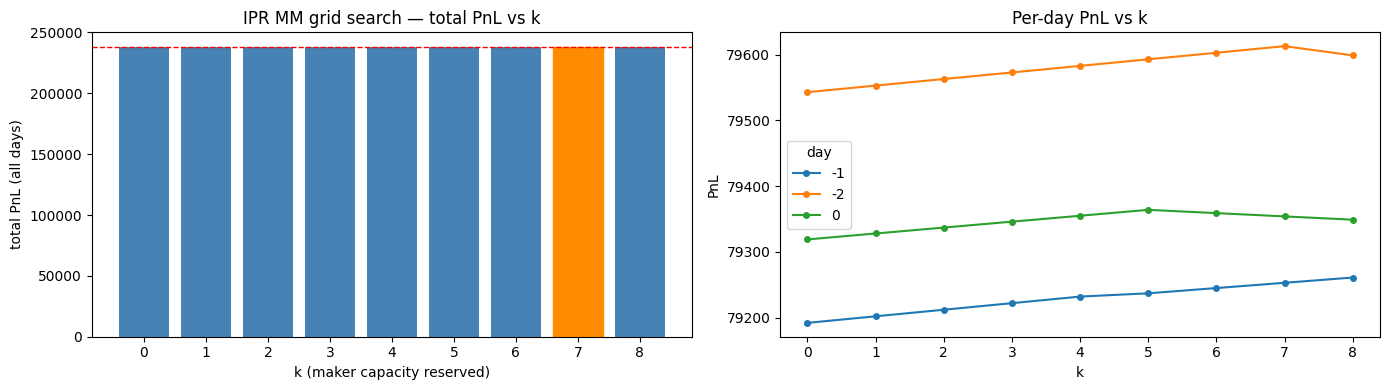


best k = 7
 k  total_pnl
 0   238054.0
 1   238083.0
 2   238112.0
 3   238141.0
 4   238170.0
 5   238194.0
 6   238207.0
 7   238220.0
 8   238209.0


In [7]:
# Plot grid search results
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# total PnL across days
axes[0].bar(agg['k'], agg['total_pnl'], color=['steelblue']*len(agg))
best_bar = agg['k'].tolist().index(best_k)
axes[0].get_children()[best_bar].set_color('darkorange')
axes[0].axhline(agg['total_pnl'].max(), color='red', lw=1, ls='--')
axes[0].set_xlabel('k (maker capacity reserved)')
axes[0].set_ylabel('total PnL (all days)')
axes[0].set_title('IPR MM grid search — total PnL vs k')
axes[0].set_xticks(agg['k'])

# per-day breakdown
pivot = results_df.pivot(index='k', columns='day', values='pnl')
pivot.plot(ax=axes[1], marker='o', ms=4)
axes[1].set_xlabel('k')
axes[1].set_ylabel('PnL')
axes[1].set_title('Per-day PnL vs k')
axes[1].set_xticks(k_values)

plt.tight_layout()
plt.show()

print(f'\nbest k = {best_k}')
print(agg.to_string(index=False))